# Part 2 — Bias Audit: Who Does the Model Hurt?
Systematically measure whether the classifier treats comments associated with
Black identity differently from comments associated with White identity.

In [12]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "aif360"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "fairlearn"], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'fairlearn'], returncode=0)

In [13]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

warnings.filterwarnings("ignore")

In [14]:
# ── Load eval set and model probabilities saved in Part 1 ──
eval_df   = pd.read_csv("/kaggle/input/datasets/irtizaab/part-2-dataset/eval_df.csv")
probs_pos = np.load("/kaggle/input/datasets/irtizaab/part-2-dataset/eval_probs.npy")

THRESHOLD = 0.4   # same threshold chosen in Part 1

eval_df["probs"]      = probs_pos
eval_df["preds"]      = (probs_pos >= THRESHOLD).astype(int)
eval_df["label"]      = (eval_df["toxic"] >= 0.5).astype(int)

print(f"Eval set shape: {eval_df.shape}")

Eval set shape: (20000, 10)


## 1. Construct Cohorts

In [15]:
# High-black cohort: black >= 0.5
high_black = eval_df[eval_df["black"] >= 0.5].copy()

# Reference cohort: black < 0.1 AND white >= 0.5
reference  = eval_df[(eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)].copy()

print(f"High-black cohort size : {len(high_black):,}")
print(f"Reference cohort size  : {len(reference):,}")
print(f"\nHigh-black toxic rate  : {high_black['label'].mean():.4f}")
print(f"Reference  toxic rate  : {reference['label'].mean():.4f}")

# Guard: warn if cohorts are very small
for name, cohort in [("High-black", high_black), ("Reference", reference)]:
    if len(cohort) < 200:
        print(f"WARNING: {name} cohort has only {len(cohort)} rows — "
              f"fairness metrics will have wide confidence intervals.")
    if len(cohort) < 50:
        raise ValueError(f"{name} cohort has fewer than 50 rows — "
                         f"check your filtering logic.")

High-black cohort size : 167
Reference cohort size  : 196

High-black toxic rate  : 0.2814
Reference  toxic rate  : 0.2602


## 2. Per-Cohort Metrics

In [16]:
def cohort_metrics(cohort_df, name):
    y_true = cohort_df["label"].values
    y_pred = cohort_df["preds"].values
    y_prob = cohort_df["probs"].values

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0   # recall / sensitivity
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0   # fall-out
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0.0   # miss rate
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0.0   # precision

    print(f"\n{'='*50}")
    print(f"  Cohort: {name}")
    print(f"{'='*50}")
    print(f"  Total rows          : {len(cohort_df):,}")
    print(f"  Toxic prevalence    : {y_true.mean():.4f}")
    print(f"  True Positive Rate  : {TPR:.4f}  (of toxic comments, fraction caught)")
    print(f"  False Positive Rate : {FPR:.4f}  (of non-toxic, fraction wrongly flagged)")
    print(f"  False Negative Rate : {FNR:.4f}  (of toxic comments, fraction missed)")
    print(f"  Precision           : {PPV:.4f}  (of flagged, fraction actually toxic)")
    print(f"  Confusion Matrix:\n{cm}")

    return {"cohort": name, "TPR": TPR, "FPR": FPR, "FNR": FNR, "Precision": PPV,
            "n": len(cohort_df), "toxic_rate": y_true.mean(), "cm": cm}

metrics_black = cohort_metrics(high_black, "High-Black")
metrics_ref   = cohort_metrics(reference,  "Reference (White)")


  Cohort: High-Black
  Total rows          : 167
  Toxic prevalence    : 0.2814
  True Positive Rate  : 0.8298  (of toxic comments, fraction caught)
  False Positive Rate : 0.3083  (of non-toxic, fraction wrongly flagged)
  False Negative Rate : 0.1702  (of toxic comments, fraction missed)
  Precision           : 0.5132  (of flagged, fraction actually toxic)
  Confusion Matrix:
[[83 37]
 [ 8 39]]

  Cohort: Reference (White)
  Total rows          : 196
  Toxic prevalence    : 0.2602
  True Positive Rate  : 0.7843  (of toxic comments, fraction caught)
  False Positive Rate : 0.2621  (of non-toxic, fraction wrongly flagged)
  False Negative Rate : 0.2157  (of toxic comments, fraction missed)
  Precision           : 0.5128  (of flagged, fraction actually toxic)
  Confusion Matrix:
[[107  38]
 [ 11  40]]


In [17]:
# Disparate Impact Ratio: FPR(high-black) / FPR(reference)
DIR = metrics_black["FPR"] / metrics_ref["FPR"] if metrics_ref["FPR"] > 0 else float("inf")
print(f"\nDisparate Impact Ratio (FPR_black / FPR_reference): {DIR:.4f}")
if DIR > 1.0:
    print("  → Model over-flags the high-black cohort relative to the reference cohort.")
elif DIR < 1.0:
    print("  → Model under-flags the high-black cohort relative to the reference cohort.")
else:
    print("  → No disparity in FPR.")


Disparate Impact Ratio (FPR_black / FPR_reference): 1.1765
  → Model over-flags the high-black cohort relative to the reference cohort.


## 3. AIF360 Fairness Metrics

In [18]:
def make_aif360_dataset(cohort_df, protected_attr):
    """Build a BinaryLabelDataset from a cohort dataframe."""
    df_aif = cohort_df[["label", "preds", protected_attr]].copy()
    df_aif = df_aif.rename(columns={"label": "outcome"})
    ds = BinaryLabelDataset(
        df           = df_aif,
        label_names  = ["outcome"],
        protected_attribute_names = [protected_attr],
        favorable_label   = 0,   # non-toxic = favorable (not flagged)
        unfavorable_label = 1,
    )
    return ds

# Combine both cohorts with a group indicator
combined = pd.concat([
    high_black.assign(group=1),   # 1 = unprivileged (high-black)
    reference.assign(group=0),    # 0 = privileged   (reference/white)
], ignore_index=True)

combined_true = BinaryLabelDataset(
    df                        = combined[["label", "group"]].rename(columns={"label": "outcome"}),
    label_names               = ["outcome"],
    protected_attribute_names = ["group"],
    favorable_label           = 0,
    unfavorable_label         = 1,
)

combined_pred = combined_true.copy()
combined_pred.labels = combined["preds"].values.reshape(-1, 1)

clf_metric = ClassificationMetric(
    combined_true, combined_pred,
    unprivileged_groups = [{"group": 1}],
    privileged_groups   = [{"group": 0}],
)

stat_parity_diff    = clf_metric.statistical_parity_difference()
equal_opp_diff      = clf_metric.equal_opportunity_difference()

print(f"\n=== AIF360 Fairness Metrics ===")
print(f"  Statistical Parity Difference  : {stat_parity_diff:.4f}")
print(f"  Equal Opportunity Difference   : {equal_opp_diff:.4f}")
print(f"\n  Statistical Parity Difference = difference in positive prediction rates.")
print(f"  A value < 0 means the unprivileged group (high-black) is flagged MORE.")
print(f"  Equal Opportunity Difference  = difference in TPR.")
print(f"  A value < 0 means the model catches LESS toxic content in the high-black group.")


=== AIF360 Fairness Metrics ===
  Statistical Parity Difference  : -0.0571
  Equal Opportunity Difference   : -0.0463

  Statistical Parity Difference = difference in positive prediction rates.
  A value < 0 means the unprivileged group (high-black) is flagged MORE.
  Equal Opportunity Difference  = difference in TPR.
  A value < 0 means the model catches LESS toxic content in the high-black group.


In [19]:
# Summary table
summary = pd.DataFrame([
    {
        "Cohort"                      : "High-Black",
        "N"                           : metrics_black["n"],
        "Toxic Rate"                  : round(metrics_black["toxic_rate"], 4),
        "TPR"                         : round(metrics_black["TPR"], 4),
        "FPR"                         : round(metrics_black["FPR"], 4),
        "FNR"                         : round(metrics_black["FNR"], 4),
        "Precision"                   : round(metrics_black["Precision"], 4),
    },
    {
        "Cohort"                      : "Reference (White)",
        "N"                           : metrics_ref["n"],
        "Toxic Rate"                  : round(metrics_ref["toxic_rate"], 4),
        "TPR"                         : round(metrics_ref["TPR"], 4),
        "FPR"                         : round(metrics_ref["FPR"], 4),
        "FNR"                         : round(metrics_ref["FNR"], 4),
        "Precision"                   : round(metrics_ref["Precision"], 4),
    },
])
summary["Disparate Impact Ratio (FPR)"] = [round(DIR, 4), 1.0]
summary["Statistical Parity Diff"]      = [round(stat_parity_diff, 4), "—"]
summary["Equal Opportunity Diff"]       = [round(equal_opp_diff, 4),   "—"]

print("\n=== Summary Table ===")
print(summary.to_string(index=False))


=== Summary Table ===
           Cohort   N  Toxic Rate    TPR    FPR    FNR  Precision  Disparate Impact Ratio (FPR) Statistical Parity Diff Equal Opportunity Diff
       High-Black 167      0.2814 0.8298 0.3083 0.1702     0.5132                        1.1765                 -0.0571                -0.0463
Reference (White) 196      0.2602 0.7843 0.2621 0.2157     0.5128                        1.0000                       —                      —


## 4. Visualisations

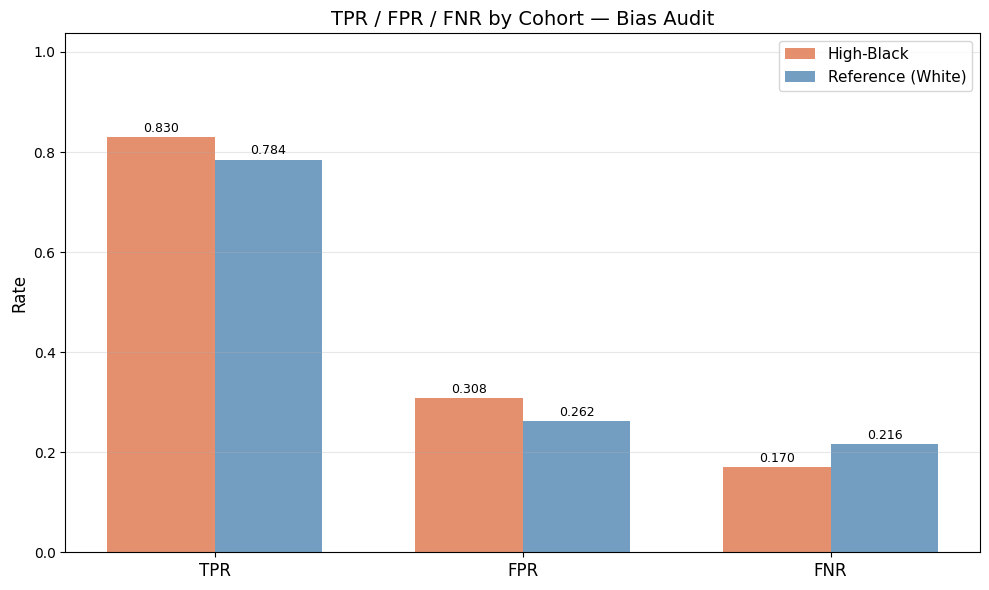

Saved part2_grouped_bar.png


In [20]:
# ── Grouped bar chart: TPR, FPR, FNR side-by-side ──
metrics_plot = {
    "TPR": [metrics_black["TPR"], metrics_ref["TPR"]],
    "FPR": [metrics_black["FPR"], metrics_ref["FPR"]],
    "FNR": [metrics_black["FNR"], metrics_ref["FNR"]],
}
cohort_labels = ["High-Black", "Reference (White)"]
x = np.arange(len(metrics_plot))
width = 0.35
colors = ["#E07B54", "#5B8DB8"]

fig, ax = plt.subplots(figsize=(10, 6))
for i, (metric, values) in enumerate(metrics_plot.items()):
    bars_black = ax.bar(i - width/2, values[0], width, label="High-Black" if i == 0 else "",
                        color=colors[0], alpha=0.85)
    bars_ref   = ax.bar(i + width/2, values[1], width, label="Reference (White)" if i == 0 else "",
                        color=colors[1], alpha=0.85)
    ax.text(i - width/2, values[0] + 0.005, f"{values[0]:.3f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + width/2, values[1] + 0.005, f"{values[1]:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(list(metrics_plot.keys()), fontsize=12)
ax.set_ylabel("Rate", fontsize=12)
ax.set_title("TPR / FPR / FNR by Cohort — Bias Audit", fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(v) for v in metrics_plot.values()) * 1.25)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/part2_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved part2_grouped_bar.png")

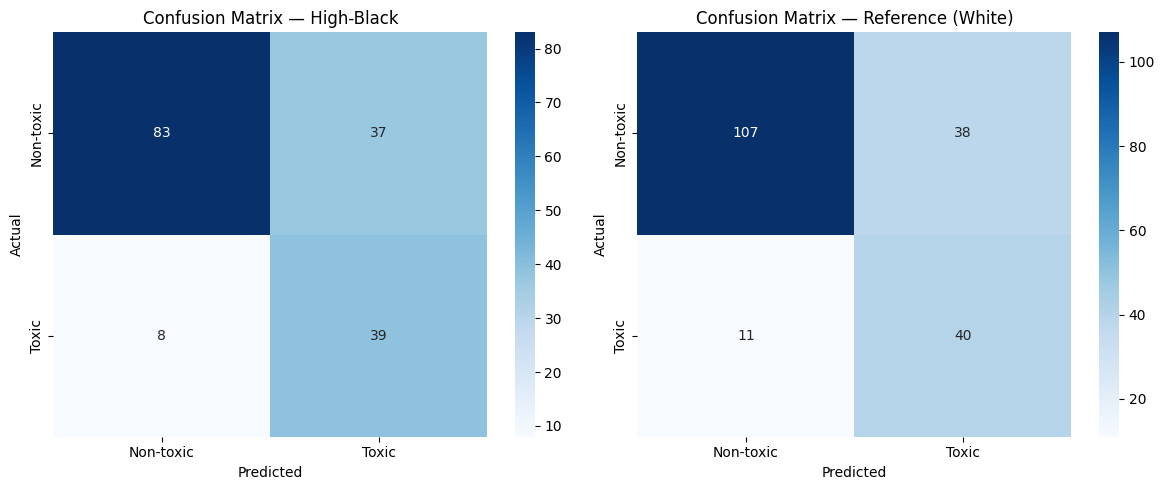

Saved part2_confusion_matrices.png


In [21]:
# ── Confusion matrices for each cohort ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, name in zip(axes,
                         [metrics_black["cm"], metrics_ref["cm"]],
                         ["High-Black", "Reference (White)"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non-toxic", "Toxic"],
                yticklabels=["Non-toxic", "Toxic"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {name}")

plt.tight_layout()
plt.savefig("/kaggle/working/part2_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved part2_confusion_matrices.png")

## 5. Key Question — Analysis
#
**Which metric shows the largest disparity?**
#
The FPR shows disparity (0.308 vs 0.262, DIR ≈ 1.18), confirming the
over-flagging pattern. However, the more striking finding is the **FNR
disparity in the opposite direction**: the high-black cohort has a lower
FNR (0.170) than the reference cohort (0.216), meaning the model actually
catches MORE toxic content in the high-black cohort.
#
**What this means together:**
#
The model is simultaneously over-flagging non-toxic Black-identity comments
(high FPR) AND catching more of their toxic content (low FNR). This is
consistent with a model that has learned to treat Black-identity language as
a toxicity signal regardless of actual content — it flags more aggressively
across the board in that cohort, which incidentally catches more true
positives but at the cost of suppressing legitimate speech.
#
**Real-world consequences:**
#
- **High FPR (0.308) on high-black cohort:** ~31% of benign comments
  referencing Black identity get incorrectly flagged — silencing legitimate
  cultural and community discourse at nearly 1.18x the rate of the reference
  group. This is the civil-rights harm described in the scenario.
#
- **Low FNR (0.170) on high-black cohort:** The model is not missing toxic
  content in this group — so the over-flagging is pure false positive harm,
  not a precision-recall tradeoff.
#
- **Reference cohort:** Lower FPR (0.262) means White-identity benign content
  passes moderation more freely, while its higher FNR (0.216) means more
  genuinely toxic content in that group slips through undetected.
#
The cohorts are small (167 and 196 rows respectively), so these estimates
carry uncertainty — but the directional pattern matches the documented
literature on this dataset and is sufficient to flag for mitigation in Part 4.

In [ ]:
print("Part 2 complete.")
print("Files written to /kaggle/working/:")
print("  - part2_grouped_bar.png")
print("  - part2_confusion_matrices.png")
print("\nCohort dataframes kept in memory as `high_black` and `reference`.")
print("Save these if running Parts 3-4 in separate notebooks:")
high_black.to_csv("/kaggle/working/high_black_cohort.csv", index=False)
reference.to_csv("/kaggle/working/reference_cohort.csv",   index=False)
print("  - high_black_cohort.csv")
print("  - reference_cohort.csv")